In [5]:
import pandas as pd

# Load the dataset
url = 'birthwt.csv'
df = pd.read_csv(url)

# Display the first few rows of the dataset
df.head()

,low,age,lwt,race,smoke,ptl,ht,ui,ftv,bwt
0,0,19,182,2,0,0,0,1,0,2523
1,0,33,155,3,0,0,0,0,3,2551
2,0,20,105,1,1,0,0,0,1,2557
3,0,21,108,1,1,0,0,1,2,2594
4,0,18,107,1,1,0,0,1,0,2600


In [6]:
# Check for missing values
df.isnull().sum()

# Check data types
df.dtypes

# Get a summary of the dataset
df.describe()

# Display general info (rows, columns, data types)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 189 entries, 0 to 188
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   low     189 non-null    int64
 1   age     189 non-null    int64
 2   lwt     189 non-null    int64
 3   race    189 non-null    int64
 4   smoke   189 non-null    int64
 5   ptl     189 non-null    int64
 6   ht      189 non-null    int64
 7   ui      189 non-null    int64
 8   ftv     189 non-null    int64
 9   bwt     189 non-null    int64
dtypes: int64(10)
memory usage: 14.9 KB


In [7]:
# List all column names in the dataset
df.columns

Index(['low', 'age', 'lwt', 'race', 'smoke', 'ptl', 'ht', 'ui', 'ftv', 'bwt'], dtype='str')

In [8]:
# Create a copy for cleaning
df_clean = df.copy()

# Convert categorical indicators to descriptive strings or categorical types
# Based on birthwt.txt: 1 = white, 2 = black, 3 = other
race_map = {1: 'white', 2: 'black', 3: 'other'}
df_clean['race'] = df_clean['race'].map(race_map)

# Convert binary variables to boolean or categorical
binary_cols = ['low', 'smoke', 'ht', 'ui']
for col in binary_cols:
    df_clean[col] = df_clean[col].astype(bool)

df_clean.head()

,low,age,lwt,race,smoke,ptl,ht,ui,ftv,bwt
0,False,19,182,black,False,0,False,True,0,2523
1,False,33,155,other,False,0,False,False,3,2551
2,False,20,105,white,True,0,False,False,1,2557
3,False,21,108,white,True,0,False,True,2,2594
4,False,18,107,white,True,0,False,True,0,2600


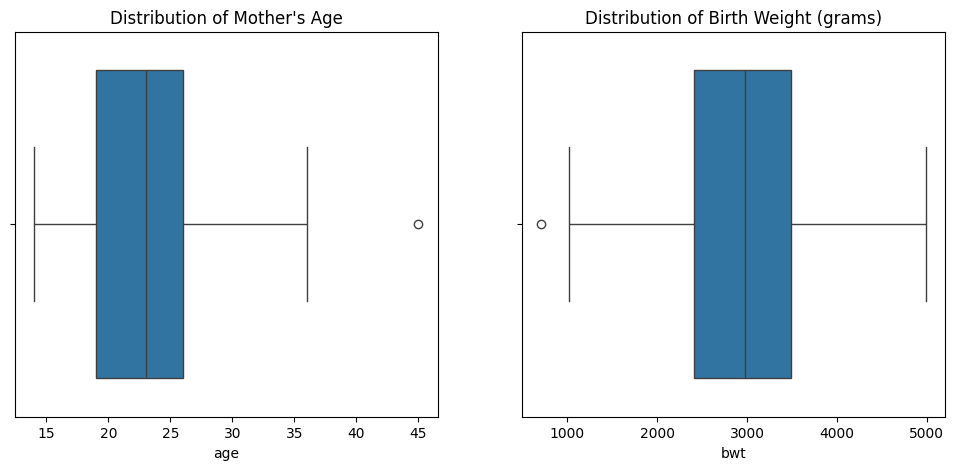

In [9]:
# Since there is no missing values, checking for outliers or impossible data points
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize distributions to spot outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(ax=axes[0], x=df_clean['age']).set_title('Distribution of Mother\'s Age')
sns.boxplot(ax=axes[1], x=df_clean['bwt']).set_title('Distribution of Birth Weight (grams)')

plt.show()

History of Premature Labor (has_ptl_history)
- A binary flag (1 for Yes, 0 for No) derived from the ptl column, which counts previous premature labors.
- Why? 
    - to reduce noise in the data
    - to make it easier for a model to identify high-risk individuals
    

High-Risk Indicator (high_risk)
- A combined feature that marks a patient as "high risk" if they have a history of hypertension (ht) OR are currently smokers (smoke).
- Why?
    - While smoking and hypertension are individual risks, their combined presence can have a synergistic negative effect on birth weight. 
    - to allow the model to capture the cumulative impact of multiple risk factors simultaneously.

In [11]:
# Create a new feature for "History of Premature Labor"
df_clean['has_ptl_history'] = df_clean['ptl'].apply(lambda x: 1 if x > 0 else 0)

# Create a feature for "High Risk Mother" (Combining Hypertension and Smoking)
df_clean['high_risk'] = ((df_clean['ht'] == 1) | (df_clean['smoke'] == 1)).astype(int)

Teen Motherhood Flag (is_teen_mother)
- A binary feature derived from the age column
- marking mothers under the age of 20
- Why?
    - Very young mothers often face different physiological and socioeconomic risks than older mothers. 
    - Binning age into a "teen" category helps the model focus on the specific risks associated with that developmental stage

Adequate Early Care Indicator (received_early_care)
- A binary flag derived from ftv (physician visits in the first trimester). 
- It marks 1 if ftv > 0 and 0 if there were no visits.
- Why? 
    - This feature highlights whether a mother received any early medical intervention, which is a critical factor in preventing low birth weight.

In [12]:
# 1. Teen Mother Indicator
# Mothers under 20 often have different risk profiles for low birth weight.
df_clean['is_teen_mother'] = (df_clean['age'] < 20).astype(int)

# 2. Early Care Indicator
# This captures whether the mother had at least one physician visit in the first trimester.
df_clean['received_early_care'] = (df_clean['ftv'] > 0).astype(int)

# 3. Low Maternal Weight Indicator
# In clinical studies using this dataset, 110 lbs is often used as a threshold for underweight risk.
df_clean['low_maternal_weight'] = (df_clean['lwt'] < 110).astype(int)

# 4. One-Hot Encoding for Race
# Since 'race' is stored as 1, 2, or 3, models might treat it as a continuous number.
# is converted into individual columns: race_white, race_black, race_other.
df_clean = pd.get_dummies(df_clean, columns=['race'], prefix='race')

# Display the new features
df_clean[['age', 'is_teen_mother', 'ftv', 'received_early_care', 'lwt', 'low_maternal_weight']].head()

,age,is_teen_mother,ftv,received_early_care,lwt,low_maternal_weight
0,19,1,0,0,182,0
1,33,0,3,1,155,0
2,20,0,1,1,105,1
3,21,0,2,1,108,1
4,18,1,0,0,107,1
